In [1]:
import pandas as pd
from pathlib import Path
import numpy as np


In [2]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("/home/jovyan/Desktop/IDX intern/california")

target_months = [
    "202411",
    "202412",
    "202501",
    "202502",
    "202503",
    "202504",
    "202505",
    "202506",
    "202507",
    "202508",
    "202509",
    "202510",
    "202511",
    "202512",
    "202601",
    "202602",
    "202603",
    "202604",
    "202605",
]

files = sorted(
    [
        f
        for f in DATA_DIR.glob("CRMLSSold*.csv")
        if any(f.name.startswith(f"CRMLSSold{m}") for m in target_months)
    ]
)

print(f"Found {len(files)} files (expecting 19):")
for f in files:
    print(f"  {f.name}")


Found 19 files (expecting 19):
  CRMLSSold202411.csv
  CRMLSSold202412.csv
  CRMLSSold202501_filled.csv
  CRMLSSold202502.csv
  CRMLSSold202503.csv
  CRMLSSold202504.csv
  CRMLSSold202505.csv
  CRMLSSold202506.csv
  CRMLSSold202507.csv
  CRMLSSold202508.csv
  CRMLSSold202509.csv
  CRMLSSold202510.csv
  CRMLSSold202511.csv
  CRMLSSold202512.csv
  CRMLSSold202601.csv
  CRMLSSold202602.csv
  CRMLSSold202603.csv
  CRMLSSold202604.csv
  CRMLSSold202605.csv


In [3]:
dfs = []
for f in files:
    try:
        tmp = pd.read_csv(f, low_memory=False)
        tmp = tmp[
            (tmp["PropertyType"] == "Residential")
            & (tmp["PropertySubType"] == "SingleFamilyResidence")
        ].copy()
        tmp["source_file"] = f.name
        dfs.append(tmp)
    except Exception as e:
        print(f"  ✗ {f.name}: {e}")

df = pd.concat(dfs, ignore_index=True)
df["CloseDate"] = pd.to_datetime(df["CloseDate"])

print(f"Total shape: {df.shape}")
print(f"Date range: {df['CloseDate'].min()} ~ {df['CloseDate'].max()}")

monthly_counts = df["CloseDate"].dt.to_period("M").value_counts().sort_index()
print(monthly_counts)

Total shape: (202798, 81)
Date range: 2024-11-01 00:00:00 ~ 2026-05-31 00:00:00
CloseDate
2024-11    10692
2024-12    10624
2025-01     8144
2025-02     8851
2025-03    10610
2025-04    11880
2025-05    11777
2025-06    11701
2025-07    12114
2025-08    11454
2025-09    11456
2025-10    12029
2025-11     9739
2025-12    10455
2026-01     7490
2026-02     8550
2026-03    11177
2026-04    12031
2026-05    12024
Freq: M, Name: count, dtype: int64


## Feature selection lists

In [4]:
location_features = [
    "Latitude",
    "Longitude",
    "City",
    "PostalCode",
    "CountyOrParish",
    "MLSAreaMajor",
    "HighSchoolDistrict",
]

property_features = [
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "YearBuilt",
    "Stories",
    "ViewYN",
    "PoolPrivateYN",
    "AttachedGarageYN",
    "GarageSpaces",
    "ParkingTotal",
]

lots_financial_final_features = [
    "AssociationFee",
    "LotSizeSquareFeet",
    "LotSizeAcres",
    "LotSizeArea",
]

all_features = location_features + property_features + lots_financial_final_features
print(f"Total features: {len(all_features)}")


Total features: 21


## ClosePrice

In [5]:
target = "ClosePrice"
df["log_price"] = np.where(df["ClosePrice"] > 0, np.log(df["ClosePrice"]), np.nan)
print("ClosePrice <= 0:", (df["ClosePrice"] <= 0).sum())
print("ClosePrice isna:", df["ClosePrice"].isna().sum())
print("log_price inf/-inf:", np.isinf(df["log_price"]).sum())
print("log_price isna:", df["log_price"].isna().sum())


ClosePrice <= 0: 1
ClosePrice isna: 1
log_price inf/-inf: 0
log_price isna: 2


/opt/base-uv/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [6]:
print(
    df[(df["ClosePrice"] <= 0) | (df["ClosePrice"].isna())][
        [
            "ClosePrice",
            "ListPrice",
            "City",
            "CountyOrParish",
            "CloseDate",
            "source_file",
        ]
    ]
)


       ClosePrice  ListPrice         City CountyOrParish  CloseDate  \
18453         NaN  2700000.0        Tracy    San Joaquin 2024-12-13   
86791         0.0  1350000.0  Temple City    Los Angeles 2025-07-30   

               source_file  
18453  CRMLSSold202412.csv  
86791  CRMLSSold202507.csv  


In [7]:
print(f"Before dropping: {len(df)}")
df = df[df["ClosePrice"] > 0].copy()
print(f"After dropping: {len(df)}")


Before dropping: 202798
After dropping: 202796


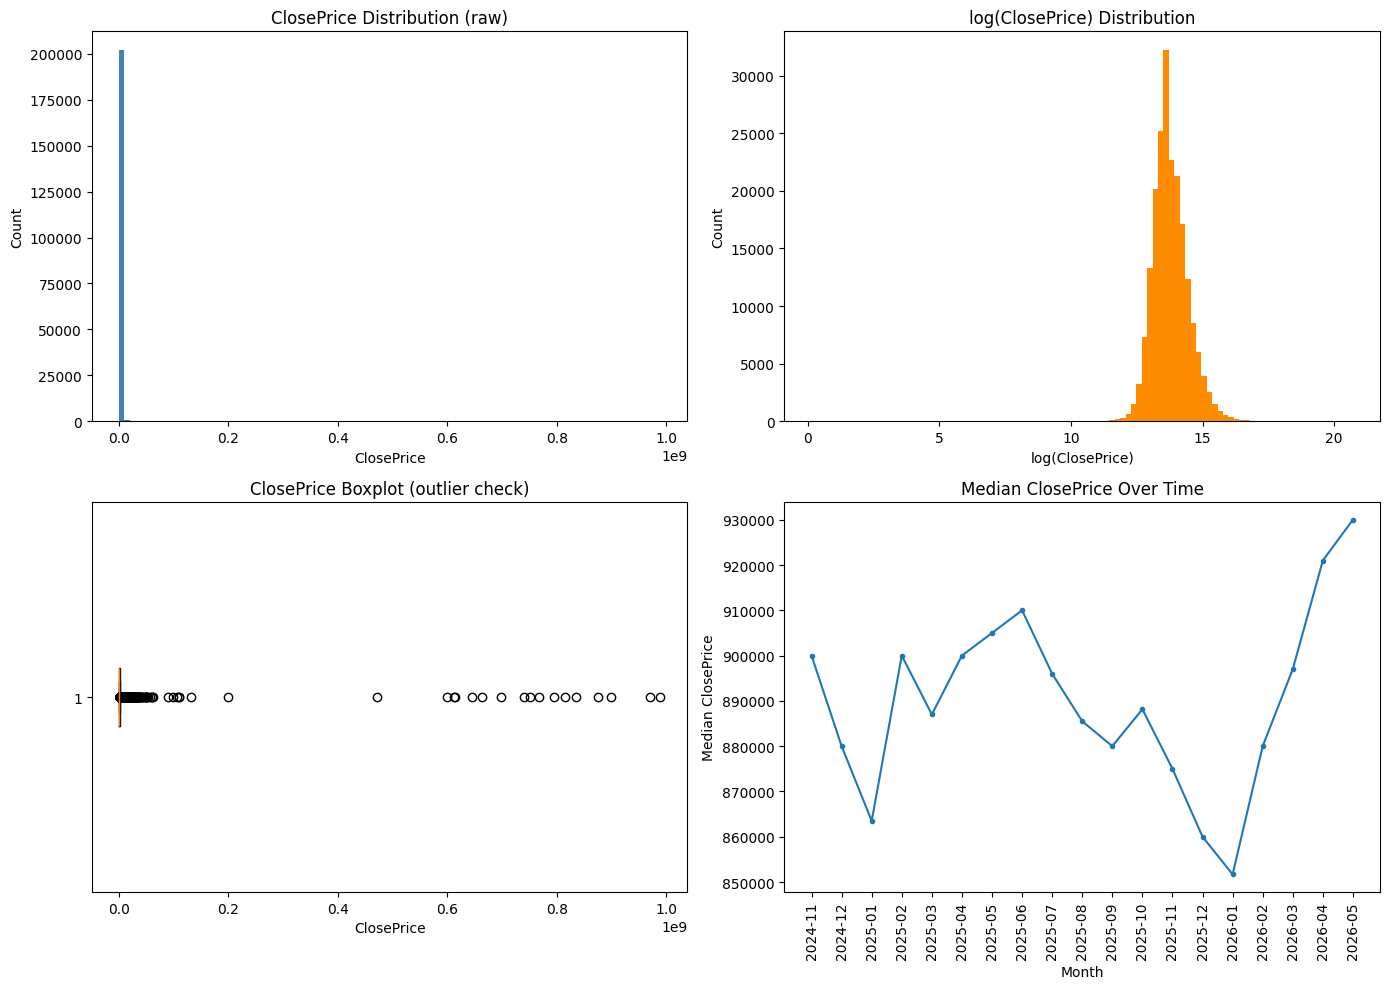

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df["ClosePrice"], bins=100, color="steelblue", edgecolor="none")
axes[0, 0].set_title("ClosePrice Distribution (raw)")
axes[0, 0].set_xlabel("ClosePrice")
axes[0, 0].set_ylabel("Count")

axes[0, 1].hist(df["log_price"], bins=100, color="darkorange", edgecolor="none")
axes[0, 1].set_title("log(ClosePrice) Distribution")
axes[0, 1].set_xlabel("log(ClosePrice)")
axes[0, 1].set_ylabel("Count")

axes[1, 0].boxplot(df["ClosePrice"].dropna(), vert=False)
axes[1, 0].set_title("ClosePrice Boxplot (outlier check)")
axes[1, 0].set_xlabel("ClosePrice")

monthly_median = df.groupby(df["CloseDate"].dt.to_period("M"))["ClosePrice"].median()
axes[1, 1].plot(
    monthly_median.index.astype(str), monthly_median.values, marker="o", markersize=3
)
axes[1, 1].set_title("Median ClosePrice Over Time")
axes[1, 1].set_xlabel("Month")
axes[1, 1].set_ylabel("Median ClosePrice")
axes[1, 1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()


In [9]:
df["price_ratio"] = df["ClosePrice"] / df["ListPrice"]

print(df["price_ratio"].describe())
print(
    df["price_ratio"].quantile(
        [0.0001, 0.0005, 0.001, 0.005, 0.995, 0.999, 0.9995, 0.9999]
    )
)


count    2.027960e+05
mean     1.085587e+00
std      8.825854e+00
min      9.591326e-07
25%      9.744355e-01
50%      1.000000e+00
75%      1.018237e+00
max      1.074981e+03
Name: price_ratio, dtype: float64
0.0001     0.096058
0.0005     0.500000
0.0010     0.638967
0.0050     0.788155
0.9950     1.375359
0.9990     1.660452
0.9995     1.946663
0.9999    82.099575
Name: price_ratio, dtype: float64


In [10]:
mask_1000x = (df["price_ratio"] > 950) | (df["price_ratio"] < 0.5)
print(f"Suspected x1000 error count: {mask_1000x.sum()}")
print(
    df.loc[mask_1000x, ["ClosePrice", "ListPrice", "price_ratio", "City", "CloseDate"]]
)


Suspected x1000 error count: 115
        ClosePrice   ListPrice  price_ratio            City  CloseDate
1787      122500.0   1199900.0     0.102092       Placentia 2024-11-26
6434      140000.0   1150000.0     0.121739           Acton 2024-11-30
9095      104090.0   1135426.0     0.091675        La Verne 2024-11-15
9233      125000.0   1355000.0     0.092251        El Monte 2024-11-12
9907      112900.0   1149000.0     0.098259        La Palma 2024-11-01
...            ...         ...          ...             ...        ...
200074     46000.0    450000.0     0.102222        Palmdale 2026-05-20
200663   7000000.0  14995000.0     0.466822  Corona Del Mar 2026-05-05
201654    485000.0   1100000.0     0.440909   San Francisco 2026-05-29
202384    372000.0   1000000.0     0.372000        Descanso 2026-05-21
202767    150000.0   1400000.0     0.107143     Palm Desert 2026-05-20

[115 rows x 5 columns]


In [11]:
lower_cap = df["price_ratio"].quantile(0.005)
upper_cap = df["price_ratio"].quantile(0.9995)
print(f"Lower cap: {lower_cap:.4f}, Upper cap: {upper_cap:.4f}")

still_suspicious = df[(df["price_ratio"] < lower_cap) | (df["price_ratio"] > upper_cap)]
print(
    f"Ratio anomaly count: {len(still_suspicious)} ({len(still_suspicious) / len(df) * 100:.4f}%)"
)

df = df[(df["price_ratio"] >= lower_cap) & (df["price_ratio"] <= upper_cap)].copy()
print(f"After price_ratio filtering: {len(df)} rows")


Lower cap: 0.7882, Upper cap: 1.9467
Ratio anomaly count: 1116 (0.5503%)
After price_ratio filtering: 201680 rows


## Geographic distribution

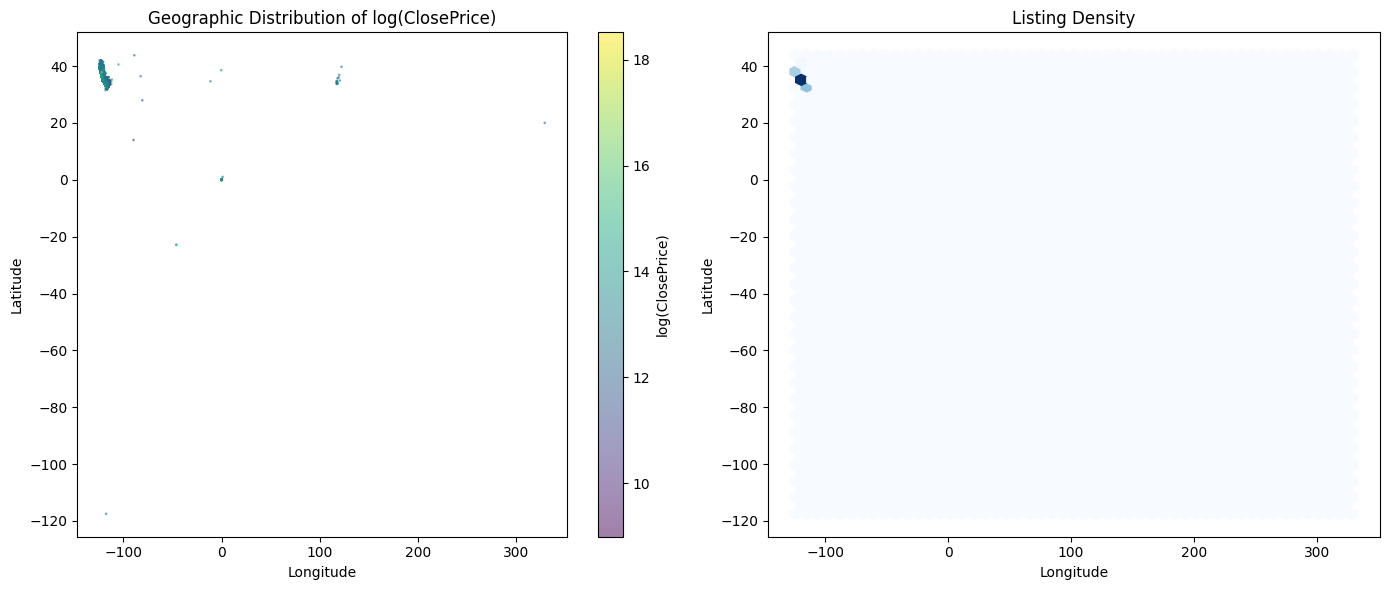

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter = axes[0].scatter(
    df["Longitude"],
    df["Latitude"],
    c=df["log_price"],
    cmap="viridis",
    s=1,
    alpha=0.5,
)
axes[0].set_title("Geographic Distribution of log(ClosePrice)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
plt.colorbar(scatter, ax=axes[0], label="log(ClosePrice)")

axes[1].hexbin(df["Longitude"], df["Latitude"], gridsize=50, cmap="Blues")
axes[1].set_title("Listing Density")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.tight_layout()
plt.show()


In [13]:
# Check for coordinates outside California's valid range
# California roughly: lat 32-42, lon -125 to -114
invalid_coords = df[
    (df["Latitude"] < 31.0)
    | (df["Latitude"] > 45)
    | (df["Longitude"] < -125.0)
    | (df["Longitude"] > -113.5)
]
print(f"Invalid coordinate count: {len(invalid_coords)}")
print(
    invalid_coords[
        ["Latitude", "Longitude", "City", "CountyOrParish", "ClosePrice"]
    ].head(20)
)


Invalid coordinate count: 55
         Latitude   Longitude                       City  CountyOrParish  \
305      0.000000    0.000000                  Hollister      San Benito   
3014  -117.472493 -117.472493                  Riverside       Riverside   
3251    39.725796  122.177762                     Orland           Glenn   
11298   34.469900  117.372200                Victorville  San Bernardino   
16838    0.000000    0.000000                  San Ramon    Contra Costa   
19126    0.000000    0.000000                  San Ramon    Contra Costa   
20002    0.000000    0.000000                     Gilroy     Santa Clara   
26999    0.000000    0.000000                     Gilroy     Santa Clara   
28957   35.263368 -111.717540                  Flagstaff           Other   
28996    0.000000    0.000000                     Gilroy     Santa Clara   
40436   36.404467  -82.356471  Outside Area (Outside Ca)     Other State   
41834   20.000000  329.000000                   Hesperia  S

In [14]:
sign_flip_mask = (
    (df["Latitude"] >= 32)
    & (df["Latitude"] <= 42)
    & (df["Longitude"] > 0)
    & (-df["Longitude"] >= -125)
    & (-df["Longitude"] <= -114)
)
print(f"Sign-flip fixable count: {sign_flip_mask.sum()}")
print(df.loc[sign_flip_mask, ["Latitude", "Longitude", "City", "CountyOrParish"]])
df.loc[sign_flip_mask, "Longitude"] = -df.loc[sign_flip_mask, "Longitude"]

Sign-flip fixable count: 14
         Latitude   Longitude                  City  CountyOrParish
3251    39.725796  122.177762                Orland           Glenn
11298   34.469900  117.372200           Victorville  San Bernardino
82730   34.480000  117.310000           Victorville  San Bernardino
103813  33.800570  118.390070  Palos Verdes Estates     Los Angeles
115484  36.000000  119.300000               Visalia          Tulare
118869  36.893100  119.760500                Fresno          Fresno
135706  34.018650  118.065830           Pico Rivera     Los Angeles
136612  34.916920  120.432670           Santa Maria   Santa Barbara
138300  33.667652  117.270769         Lake Elsinore       Riverside
138885  33.937295  117.260059         Moreno Valley       Riverside
153590  34.423064  117.366349              Hesperia  San Bernardino
159735  35.691123  118.140030             Lancaster     Los Angeles
181769  33.920651  117.467524             Riverside       Riverside
182705  34.728660  1

In [15]:
invalid_coords = df[
    (df["Latitude"] < 31.0)
    | (df["Latitude"] > 45)
    | (df["Longitude"] < -125.0)
    | (df["Longitude"] > -113.5)
]
print(f"Invalid coordinate count: {len(invalid_coords)}")
print(invalid_coords[["Latitude", "Longitude", "City", "CountyOrParish", "ClosePrice"]])


Invalid coordinate count: 41
          Latitude   Longitude                       City   CountyOrParish  \
305       0.000000    0.000000                  Hollister       San Benito   
3014   -117.472493 -117.472493                  Riverside        Riverside   
16838     0.000000    0.000000                  San Ramon     Contra Costa   
19126     0.000000    0.000000                  San Ramon     Contra Costa   
20002     0.000000    0.000000                     Gilroy      Santa Clara   
26999     0.000000    0.000000                     Gilroy      Santa Clara   
28957    35.263368 -111.717540                  Flagstaff            Other   
28996     0.000000    0.000000                     Gilroy      Santa Clara   
40436    36.404467  -82.356471  Outside Area (Outside Ca)      Other State   
41834    20.000000  329.000000                   Hesperia   San Bernardino   
57642     0.000000    0.000000                    Compton      Los Angeles   
58454     0.000000    0.000000     

In [16]:
df = df[~df.index.isin(invalid_coords.index)].copy()
print(f"Final row count: {len(df)}")


Final row count: 201639


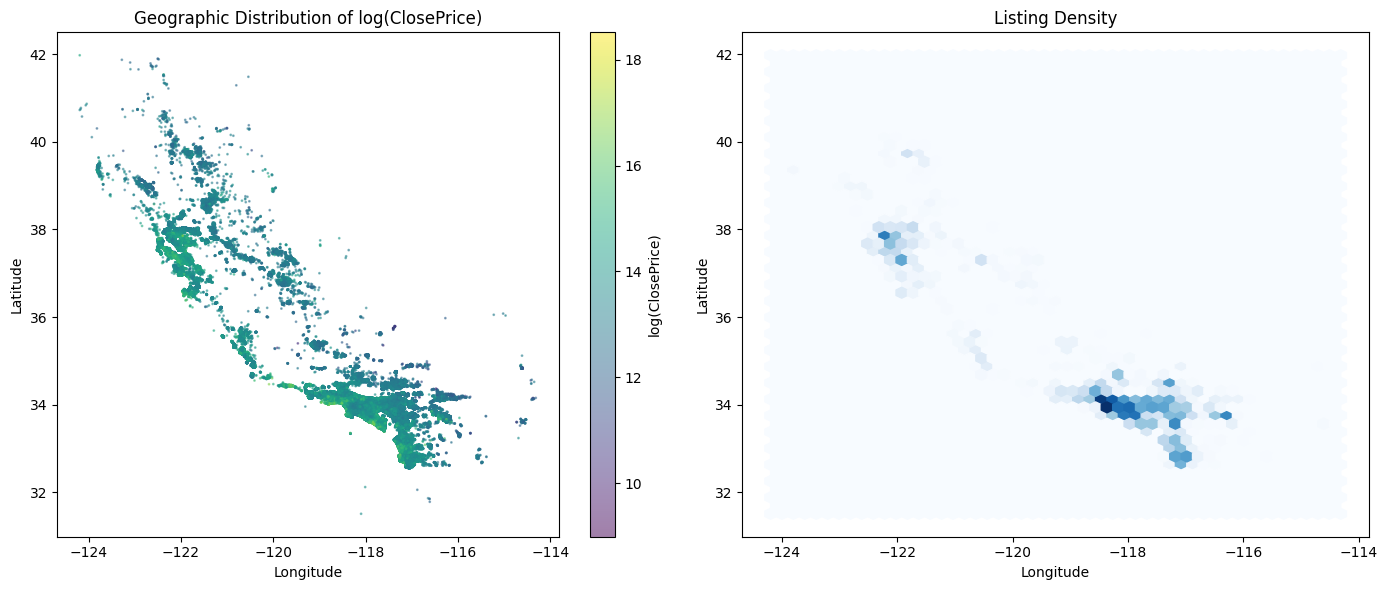

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter = axes[0].scatter(
    df["Longitude"], df["Latitude"], c=df["log_price"], cmap="viridis", s=1, alpha=0.5
)
axes[0].set_title("Geographic Distribution of log(ClosePrice)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
plt.colorbar(scatter, ax=axes[0], label="log(ClosePrice)")

axes[1].hexbin(df["Longitude"], df["Latitude"], gridsize=50, cmap="Blues")
axes[1].set_title("Listing Density")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.tight_layout()
plt.show()


## Missing rate

In [18]:
print(f"ClosePrice missing count: {df['ClosePrice'].isna().sum()}")
print(f"ClosePrice missing pct: {df['ClosePrice'].isna().mean() * 100:.4f}%")


ClosePrice missing count: 0
ClosePrice missing pct: 0.0000%


In [19]:
missing_summary = df[all_features].isna().mean().sort_values(ascending=False) * 100
missing_summary = missing_summary.round(2).to_frame("missing_pct")
missing_summary["dtype"] = df[all_features].dtypes.astype(str)
print(missing_summary)


                       missing_pct    dtype
AssociationFee               29.40  float64
HighSchoolDistrict           26.66   object
MLSAreaMajor                 14.39   object
AttachedGarageYN             11.85   object
Stories                      11.23  float64
ViewYN                        8.98   object
PoolPrivateYN                 8.31   object
GarageSpaces                  3.87  float64
LotSizeAcres                  1.74  float64
LotSizeSquareFeet             1.74  float64
LotSizeArea                   1.73  float64
YearBuilt                     0.07  float64
City                          0.06   object
LivingArea                    0.05  float64
BathroomsTotalInteger         0.01  float64
Longitude                     0.01  float64
Latitude                      0.01  float64
ParkingTotal                  0.00  float64
PostalCode                    0.00   object
BedroomsTotal                 0.00  float64
CountyOrParish                0.00   object


### AssociationFee

In [20]:
print(df["AssociationFee"].describe())
print((df["AssociationFee"] == 0).sum())


count    142361.000000
mean        104.897268
std         331.590099
min           0.000000
25%           0.000000
50%           0.000000
75%         130.000000
max       20712.000000
Name: AssociationFee, dtype: float64
90805


In [21]:
df["AssociationFee_missing"] = df["AssociationFee"].isna().astype(int)
df["AssociationFee"] = df["AssociationFee"].fillna(0)


### HighSchoolDistrict, MLSAreaMajor


In [22]:
for col in ["HighSchoolDistrict", "MLSAreaMajor"]:
    df[f"{col}_missing"] = df[col].isna().astype(int)
    df[col] = df[col].fillna("Missing")

print(
    df[
        [
            "HighSchoolDistrict",
            "HighSchoolDistrict_missing",
            "MLSAreaMajor",
            "MLSAreaMajor_missing",
        ]
    ]
    .isna()
    .sum()
)


HighSchoolDistrict            0
HighSchoolDistrict_missing    0
MLSAreaMajor                  0
MLSAreaMajor_missing          0
dtype: int64


### ViewYN, PoolPrivateYN, AttachedGarageYN

In [23]:
for col in ["ViewYN", "PoolPrivateYN", "AttachedGarageYN"]:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))



ViewYN:
ViewYN
True     112398
False     71132
NaN       18109
Name: count, dtype: int64

PoolPrivateYN:
PoolPrivateYN
False    153936
True      30937
NaN       16766
Name: count, dtype: int64

AttachedGarageYN:
AttachedGarageYN
True     148266
False     29469
NaN       23904
Name: count, dtype: int64


In [24]:
for col in ["ViewYN", "PoolPrivateYN", "AttachedGarageYN"]:
    df[f"{col}_missing"] = df[col].isna().astype(int)
    df[col] = df[col].astype(object).fillna("Missing")

print(
    df[
        [
            "ViewYN",
            "ViewYN_missing",
            "PoolPrivateYN",
            "PoolPrivateYN_missing",
            "AttachedGarageYN",
            "AttachedGarageYN_missing",
        ]
    ]
    .isna()
    .sum()
)


ViewYN                      0
ViewYN_missing              0
PoolPrivateYN               0
PoolPrivateYN_missing       0
AttachedGarageYN            0
AttachedGarageYN_missing    0
dtype: int64


### Stories

In [25]:
print(df["Stories"].describe())
print(df["Stories"].value_counts(dropna=False).sort_index())


count    178986.000000
mean          1.352111
std           0.477630
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max           2.000000
Name: Stories, dtype: float64
Stories
1.0    115963
2.0     63023
NaN     22653
Name: count, dtype: int64


In [26]:
df["Stories_missing"] = df["Stories"].isna().astype(int)
df["Stories"] = df["Stories"].fillna(df["Stories"].median())

print(df["Stories"].isna().sum())
print(df["Stories"].value_counts())


0
Stories
1.0    138616
2.0     63023
Name: count, dtype: int64


### missing rate <5%

In [27]:
# Numeric columns: impute with median + missing flag
numeric_low_missing = [
    "GarageSpaces",
    "LotSizeSquareFeet",
    "LotSizeAcres",
    "LotSizeArea",
    "YearBuilt",
    "LivingArea",
    "Longitude",
    "BathroomsTotalInteger",
    "Latitude",
    "ParkingTotal",
]

for col in numeric_low_missing:
    df[f"{col}_missing"] = df[col].isna().astype(int)
    df[col] = df[col].fillna(df[col].median())

# Categorical column with negligible missing rate: just drop those rows
df = df.dropna(subset=["City"])

print(df[numeric_low_missing + ["City"]].isna().sum())
print(f"\nFinal row count: {len(df)}")


GarageSpaces             0
LotSizeSquareFeet        0
LotSizeAcres             0
LotSizeArea              0
YearBuilt                0
LivingArea               0
Longitude                0
BathroomsTotalInteger    0
Latitude                 0
ParkingTotal             0
City                     0
dtype: int64

Final row count: 201525


## train/test split

In [28]:
def three_way_time_split(df, date_col="CloseDate"):
    train_df = df[(df[date_col] >= "2024-11-01") & (df[date_col] < "2025-12-01")].copy()
    val_df = df[(df[date_col] >= "2025-12-01") & (df[date_col] < "2026-03-01")].copy()
    test_df = df[(df[date_col] >= "2026-03-01") & (df[date_col] < "2026-06-01")].copy()
    return train_df, val_df, test_df


train_df, val_df, test_df = three_way_time_split(df)

print(
    f"Train: {len(train_df)} rows | {train_df['CloseDate'].min().date()} ~ {train_df['CloseDate'].max().date()}"
)
print(
    f"Val:   {len(val_df)} rows | {val_df['CloseDate'].min().date()} ~ {val_df['CloseDate'].max().date()}"
)
print(
    f"Test:  {len(test_df)} rows | {test_df['CloseDate'].min().date()} ~ {test_df['CloseDate'].max().date()}"
)


Train: 140184 rows | 2024-11-01 ~ 2025-11-30
Val:   26307 rows | 2025-12-01 ~ 2026-02-28
Test:  35034 rows | 2026-03-01 ~ 2026-05-31


## categorical fields encoding

In [29]:
categorical_cols_high_card = [
    "City",
    "PostalCode",
    "CountyOrParish",
    "MLSAreaMajor",
    "HighSchoolDistrict",
]


def smoothed_target_encoding(train, others, col, target_col="log_price", smoothing=10):
    global_mean = train[target_col].mean()
    agg = train.groupby(col)[target_col].agg(["mean", "count"])
    smoothed = (agg["mean"] * agg["count"] + global_mean * smoothing) / (
        agg["count"] + smoothing
    )

    train[f"{col}_encoded"] = train[col].map(smoothed)
    for o in others:
        o[f"{col}_encoded"] = o[col].map(smoothed).fillna(global_mean)
    return train, others


for col in categorical_cols_high_card:
    train_df, (val_df, test_df) = smoothed_target_encoding(
        train_df, [val_df, test_df], col
    )

print("Target encoding done:")
print(train_df[[f"{c}_encoded" for c in categorical_cols_high_card]].describe())


Target encoding done:
        City_encoded  PostalCode_encoded  CountyOrParish_encoded  \
count  140184.000000       140184.000000           140184.000000   
mean       13.787732           13.786364               13.784972   
std         0.518030            0.530264                0.402806   
min        12.371747           12.371747               12.737057   
25%        13.448370           13.402303               13.415322   
50%        13.773514           13.751487               13.958652   
75%        14.126448           14.123214               13.971058   
max        15.591087           15.591087               14.581966   

       MLSAreaMajor_encoded  HighSchoolDistrict_encoded  
count         140184.000000               140184.000000  
mean              13.782332                   13.787945  
std                0.457093                    0.428027  
min               12.371747                   12.547885  
25%               13.497475                   13.555790  
50%              

In [30]:
# Low-cardinality categorical columns (YN flags): one-hot encoding
simple_cat_cols = ["ViewYN", "PoolPrivateYN", "AttachedGarageYN"]

for col in simple_cat_cols:
    train_df[col] = train_df[col].astype(str)
    val_df[col] = val_df[col].astype(str)
    test_df[col] = test_df[col].astype(str)

train_df = pd.get_dummies(train_df, columns=simple_cat_cols, drop_first=True)
val_df = pd.get_dummies(val_df, columns=simple_cat_cols, drop_first=True)
test_df = pd.get_dummies(test_df, columns=simple_cat_cols, drop_first=True)

train_df, val_df = train_df.align(val_df, join="left", axis=1, fill_value=0)
train_df, test_df = train_df.align(test_df, join="left", axis=1, fill_value=0)

print("\nOne-hot encoding done. New columns:")
print([c for c in train_df.columns if any(c.startswith(p) for p in simple_cat_cols)])



One-hot encoding done. New columns:
['ViewYN_missing', 'PoolPrivateYN_missing', 'AttachedGarageYN_missing', 'ViewYN_Missing', 'ViewYN_True', 'PoolPrivateYN_Missing', 'PoolPrivateYN_True', 'AttachedGarageYN_Missing', 'AttachedGarageYN_True']


In [31]:
print(df[["Latitude_missing", "Longitude_missing"]].value_counts())


Latitude_missing  Longitude_missing
0                 0                    201508
1                 1                        17
Name: count, dtype: int64


## Define final feature list for modeling

In [35]:
location_encoded = [f"{c}_encoded" for c in categorical_cols_high_card]
location_raw_numeric = ["Latitude", "Longitude"]

property_features_final = [
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "YearBuilt",
    "Stories",
    "GarageSpaces",
    "ParkingTotal",
]

lots_financial_final_features = [
    "AssociationFee",
    "LotSizeSquareFeet",
    "LotSizeAcres",
    "LotSizeArea",
]

missing_flags = [c for c in train_df.columns if c.endswith("_missing")]

yn_missing_flags = [f"{c}_missing" for c in simple_cat_cols]
missing_flags = [c for c in missing_flags if c not in yn_missing_flags]

missing_flags = [c for c in missing_flags if c != "Longitude_missing"]

onehot_cols = [
    c
    for c in train_df.columns
    if any(c.startswith(p) for p in simple_cat_cols) and not c.endswith("_missing")
]

feature_cols = (
    location_encoded
    + location_raw_numeric
    + property_features_final
    + lots_financial_final_features
    + missing_flags
    + onehot_cols
)
feature_cols = list(dict.fromkeys(feature_cols))

missing_from_df = [c for c in feature_cols if c not in train_df.columns]
print(f"Missing columns: {missing_from_df}")

X_train = train_df[feature_cols]
X_val = val_df[feature_cols]
X_test = test_df[feature_cols]
y_train = train_df["log_price"]
y_val = val_df["log_price"]
y_test = test_df["log_price"]

print(f"Final feature count: {len(feature_cols)}")

Missing columns: []
Final feature count: 37


In [ ]:
print("ViewYN_missing" in feature_cols)
print("PoolPrivateYN_missing" in feature_cols)
print("AttachedGarageYN_missing" in feature_cols)
print("Longitude_missing" in feature_cols)
print(f"Total feature count: {len(feature_cols)}")


False
False
False
False
Total feature count: 37


##  export CSV 

In [37]:
non_numeric_check = X_train.select_dtypes(include=["object"]).columns.tolist()
print(
    f"Non-numeric columns in final feature set (should be empty): {non_numeric_check}"
)

train_export = X_train.copy()
train_export["log_price"] = y_train
train_export["ClosePrice"] = train_df["ClosePrice"]

val_export = X_val.copy()
val_export["log_price"] = y_val
val_export["ClosePrice"] = val_df["ClosePrice"]

test_export = X_test.copy()
test_export["log_price"] = y_test
test_export["ClosePrice"] = test_df["ClosePrice"]

train_export.to_csv("train.csv", index=False)
val_export.to_csv("validation.csv", index=False)
test_export.to_csv("test.csv", index=False)

print(f"\ntrain.csv: {train_export.shape}")
print(f"validation.csv: {val_export.shape}")
print(f"test.csv: {test_export.shape}")


Non-numeric columns in final feature set (should be empty): []

train.csv: (140184, 39)
validation.csv: (26307, 39)
test.csv: (35034, 39)
